In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import torchvision.models.segmentation as seg_models

In [2]:
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)

3

#### define the paths 

In [3]:
traindata_path = '/home/pranav/Epoch/archive(1)/tiff/train'
traindata_labels_path = '/home/pranav/Epoch/archive(1)/tiff/train_labels'
validdata_path = '/home/pranav/Epoch/archive(1)/tiff/val'
validdata_labels_path = '/home/pranav/Epoch/archive(1)/tiff/val_labels'
testdata_path = '/home/pranav/Epoch/archive(1)/tiff/test'
testdata_labels_path = '/home/pranav/Epoch/archive(1)/tiff/test_labels'

#### defined the path of the first image of checks and debugging

In [57]:
pth_first = os.path.join(traindata_path, '10078660_15.tiff')
pth_first_label = os.path.join(traindata_labels_path,'10078660_15.tif')

#### function to display the image whose path is given

In [58]:
#write a fun to display the images 
def display_img (image_path , index=0, islabel= 0):
    #this is the list of the image paths that are of ext .tiff in the dir 
    if islabel == 1 :
        ext = '.tif'
    else :
        ext = '.tiff'
    image_files = sorted([f for f in os.listdir(image_path) if f.endswith(ext)])
    
    img = cv2.imread(os.path.join(image_path, image_files[index]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


#### checking

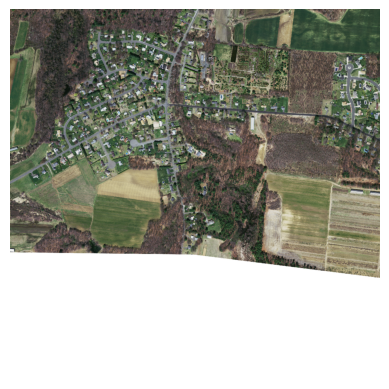

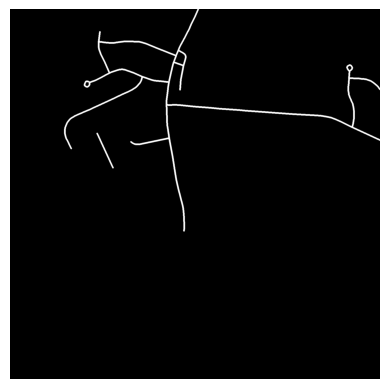

In [59]:
display_img('/home/pranav/Epoch/archive(1)/tiff/train')
display_img(traindata_labels_path,islabel=1)

lets check the class imbalance 

In [60]:
def class_imbalance (image_path):
    image_file = sorted([f for f in os.listdir(image_path)])
    total = 0
    total_white=0
    for file in image_file:
        img = cv2.imread(os.path.join(image_path,file),cv2.IMREAD_GRAYSCALE)
    
        total_white += np.sum(img > 127)
        total += img.size
    
    return float((total_white/total) *100)

In [61]:
class_imbalance(traindata_labels_path)
#so the total white in the whole dataset is not even 5 percent

4.7696206578419575

#### resolution


In [62]:
#lets see the image resolution 
def resolution (image_path):
    img = cv2.imread(image_path)
    return img.shape

In [63]:
#resolution of the image 
height,width,channels =resolution(pth_first)
print(f'The image is {height}x{width}x{channels}')

#resolution of the mask 
height_m,width_m ,channels = resolution(pth_first_label)
print(f"The mask is {height_m}x{width_m}x{channels}")

The image is 1500x1500x3
The mask is 1500x1500x3


#### checking

In [64]:
image_first_mask = cv2.imread(pth_first_label,cv2.IMREAD_GRAYSCALE)

print(list(np.unique(image_first_mask)))
#so its only 0 and 255 in the masks

[np.uint8(0), np.uint8(255)]


#### lets define a padding function (this function also normalizes and binarizes)

In [4]:

def padding (image_path, mask = 0): #mask = 0 => image not mask
    if mask == 0:
        img = cv2.imread((image_path)) #so the img has the np array of 1500x1500x3

        #normalize the img
        img = np.float32(img / 255)

        image_padded = np.pad(img,((18,18), (18,18),(0,0)) , mode='constant',constant_values=0)
    else :
        img = cv2.imread((image_path), cv2.IMREAD_GRAYSCALE)
        #we will also convert the 255 in the masks to 1 in the array
        img = np.uint(img / 255)
        image_padded = np.pad(img,((18,18), (18,18)) , mode='constant',constant_values=0)
    
    return image_padded #1536x1536x3 for image and 1536x1536x1 for mask 


In [66]:
#just to check
img1 = padding(pth_first)
print(img1.shape)
#print(np.unique(img1))
img = padding(pth_first_label, mask=1)
print(np.unique(img))

(1536, 1536, 3)
[0 1]


#### now we need to crop the images of 1536x1536 into 36 of 256x256

In [5]:
def crop (image_file,mask=0):
    
    
    
    img_crp =[]
    #lets first pad the image 
    image_padded = padding(image_file,mask=mask)
        
    #now slice out 512x512x3 pieces

    rows = image_padded.shape[0] // 256
    cols = image_padded.shape[1] // 256
    current = 0
    for x in range(rows):
        current_y = 0
        for y in range(cols):
            if mask == 0:
                img_crp.append(image_padded[current:current+256, current_y:current_y + 256, :])
            else :
                img_crp.append(image_padded[current:current+256, current_y:current_y + 256])
            current_y += 256
        current += 256

    
        

    
    

    return np.array(img_crp)



In [68]:
test_crop = crop (pth_first_label,mask=1)

In [69]:
test_crop.shape

(36, 256, 256)

### UNet class

In [6]:
#creating the unet class 
#later converted from 5 layers to 3
class UNET (nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        


        self.l1cnn1 = nn.Conv2d(in_channels=3,out_channels=64,stride=1,padding=1,kernel_size=3)
        self.l1cnn2 = nn.Conv2d(in_channels=64,out_channels=64,stride=1,padding=1,kernel_size=3)
        
        self.l2cnn1 = nn.Conv2d(in_channels=64,out_channels=128,stride=1,padding=1,kernel_size=3)
        self.l2cnn2 = nn.Conv2d(in_channels=128,out_channels=128,stride=1,padding=1,kernel_size=3)

        self.l3cnn1 = nn.Conv2d(in_channels=128,out_channels=256,stride=1,padding=1,kernel_size=3)
        self.l3cnn2 = nn.Conv2d(in_channels=256,out_channels=256,stride=1,padding=1,kernel_size=3)

        #self.l4cnn1 = nn.Conv2d(in_channels=256,out_channels=512,stride=1,padding=1,kernel_size=3)
        #self.l4cnn2 = nn.Conv2d(in_channels=512,out_channels=512,stride=1,padding=1,kernel_size=3)

        #self.l5cnn1 = nn.Conv2d(in_channels=512,out_channels=1024,stride=1,padding=1,kernel_size=3)
        #self.l5cnn2 = nn.Conv2d(in_channels=1024,out_channels=1024,stride=1,padding=1,kernel_size=3)
        
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2,padding=0)
        #self.upconv1 = nn.ConvTranspose2d(in_channels=1024,out_channels=512,kernel_size=2,stride=2,padding=0)
        #self.upconv2 = nn.ConvTranspose2d(in_channels=512,out_channels=256,kernel_size=2,stride=2,padding=0)
        self.upconv3 = nn.ConvTranspose2d(in_channels=256,out_channels=128,kernel_size=2,stride=2,padding=0)
        self.upconv4 = nn.ConvTranspose2d(in_channels=128,out_channels=64,kernel_size=2,stride=2,padding=0)

        #self.dl4cnn1 = nn.Conv2d(in_channels=1024,out_channels=512,stride=1,padding=1,kernel_size=3)
        #self.dl4cnn2 = nn.Conv2d(in_channels=512,out_channels=512,stride=1,padding=1,kernel_size=3)
        
        #self.dl3cnn1 = nn.Conv2d(in_channels=512,out_channels=256,stride=1,padding=1,kernel_size=3)
        #self.dl3cnn2 = nn.Conv2d(in_channels=256,out_channels=256,stride=1,padding=1,kernel_size=3)

        self.dl2cnn1 = nn.Conv2d(in_channels=256,out_channels=128,stride=1,padding=1,kernel_size=3)
        self.dl2cnn2 = nn.Conv2d(in_channels=128,out_channels=128,stride=1,padding=1,kernel_size=3)

        self.dl1cnn1 = nn.Conv2d(in_channels=128,out_channels=64,stride=1,padding=1,kernel_size=3)
        self.dl1cnn2 = nn.Conv2d(in_channels=64,out_channels=64,stride=1,padding=1,kernel_size=3)

        self.outcnn2 = nn.Conv2d(in_channels=64,out_channels=1,stride=1,padding=0,kernel_size=1)
        
        self.fun= nn.ReLU()
        
        self.norm1 = nn.BatchNorm2d(num_features=64) #num_features = num of channels in input
        self.norm2 = nn.BatchNorm2d(num_features=128)
        self.norm3 = nn.BatchNorm2d(num_features=256)
        
        

    def forward (self,image):
        l1cnn1 = self.fun (self.norm1(self.l1cnn1(image)))
        l1cnn2 = self.fun (self.norm1(self.l1cnn2(l1cnn1)))
        pool1 = self.pool(l1cnn2)

        l2cnn1 = self.fun (self.norm2(self.l2cnn1(pool1)))
        l2cnn2 = self.fun (self.norm2(self.l2cnn2(l2cnn1)))
        pool2 = self.pool(l2cnn2)

        l3cnn1 = self.fun (self.norm3(self.l3cnn1(pool2)))
        l3cnn2 = self.fun (self.norm3(self.l3cnn2(l3cnn1)))
        #pool3 = self.pool(l3cnn2)

        #l4cnn1 = self.fun (self.l4cnn1(pool3))
        #l4cnn2 = self.fun (self.l4cnn2(l4cnn1))
        #pool4 = self.pool(l4cnn2)

        #l5cnn1 = self.fun (self.l5cnn1(pool4))
        #l5cnn2 = self.fun (self.l5cnn2(l5cnn1))

        y1 =self.upconv3(l3cnn2)
        
        x1 = torch.cat((l2cnn2,y1),dim = 1) #dim = 1 because shape is (batch, channels, H, W)

        dl2cnn1 = self.fun (self.norm2(self.dl2cnn1(x1)))
        dl2cnn2 = self.fun (self.norm2(self.dl2cnn2(dl2cnn1)))

        y2 = self.upconv4(dl2cnn2)

        x2 = torch.cat((l1cnn2,y2),dim =1)

        #dl3cnn1 = self.fun (self.dl3cnn1(x2))
        #dl3cnn2 = self.fun (self.dl3cnn2(dl3cnn1))

        #y3 = self.upconv3(dl3cnn2)

        #x3 = torch.cat((l2cnn2,y3),dim = 1)

        #dl2cnn1 = self.fun (self.dl2cnn1(x3))
        #dl2cnn2 = self.fun (self.dl2cnn2(dl2cnn1))

        #y4 = self.upconv4(dl2cnn2)

        #x4 = torch.cat((l1cnn2,y4),dim = 1)

        dl1cnn1 = self.fun (self.norm1(self.dl1cnn1(x2)))
        dl1cnn2 = self.fun (self.norm1(self.dl1cnn2(dl1cnn1)))


        mask = (self.outcnn2(dl1cnn2))

        return mask


In [7]:
class InteractionDataset(Dataset):
    def __init__(self, image_path, mask_path, amount=30):
        super().__init__()
        self.image = image_path
        self.mask = mask_path
        self.image_file_full = sorted([f for f in os.listdir(image_path)])
        self.image_file = self.image_file_full[0:amount]
        self.mask_file_full = sorted([f for f in os.listdir(mask_path)])
        self.mask_file = self.mask_file_full[0:amount]

        self._cached_img_index = None
        self._cached_images_cropped = None
        self._cached_masks_cropped = None

    def __len__(self):
        return len(self.image_file) * 36

    def __getitem__(self, index):
        img_index = index // 36
        patch_idx = index % 36

        if img_index != self._cached_img_index:
            self._cached_images_cropped = crop(os.path.join(self.image, self.image_file[img_index]))
            self._cached_masks_cropped = crop(os.path.join(self.mask, self.mask_file[img_index]), mask=1)
            self._cached_img_index = img_index

        image_patch = self._cached_images_cropped[patch_idx]
        mask_patch = self._cached_masks_cropped[patch_idx]

        image_tensor = torch.from_numpy(image_patch).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask_patch).unsqueeze(0).float()

        return image_tensor, mask_tensor

In [8]:
train_dataset = InteractionDataset(traindata_path, traindata_labels_path)
val_dataset = InteractionDataset(validdata_path, validdata_labels_path)
test_dataset = InteractionDataset(testdata_path, testdata_labels_path)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=5)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=4)

#### was used while handling OOM error

In [74]:
print(torch.cuda.memory_allocated() / 1e9)
print(torch.cuda.memory_allocated() / 1e9, torch.cuda.memory_reserved() / 1e9)
print(torch.cuda.memory_allocated() / 1e9)
        


0.085233664
0.085233664 3.605004288
0.085233664


### Diceloss

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        union = probs.sum() + targets.sum()

        dice_coeff = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_coeff

### BCE + Dice

In [10]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth)

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

In [11]:
def dice_score(pred, target, smooth=1e-6):
    return 1 - DiceLoss(smooth)(pred, target)



In [18]:
def train (model,trainloader , validationloader ,lossfun, num_epochs = 20 , lr=0.001,weight_decay=0):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr = lr ,weight_decay=weight_decay)
    criterion = lossfun

    

    for epoch in range(num_epochs):
        # Training
        model.train()
        total_loss = 0
        for images , masks in trainloader:
            images = images.to(device)
            #print(images.min().item(), images.max().item())
            masks = masks.to(device)
            
            optimizer.zero_grad()
            output = model(images)          
            loss = criterion(output, masks) 
            loss.backward()


            
            optimizer.step()
            total_loss += loss.item()

        
        # Validation
        model.eval()
        val_loss = 0
        val_dice = 0
        val_iou = 0
        with torch.no_grad():                               #to not change the grads
            for images, masks in validationloader:
                images = images.to(device)
                masks = masks.to(device)
                output = model(images)

                val_loss += criterion(output, masks).item()

                val_dice += dice_score(output,masks).item()
                avg_dice = val_dice/len(validationloader)

                
        print(f"Epoch {epoch+1} | Train Loss: {total_loss/len(trainloader):.4f} | "f"Val Loss: {val_loss/len(validationloader):.4f} | Val Dice: {avg_dice:.4f}")

    

In [79]:
model_bce = UNET()
logs_bce = train(model_bce, train_loader, val_loader, nn.BCEWithLogitsLoss(), num_epochs=5)



Epoch 1 | Train Loss: 0.2164 | Val Loss: 0.2827 | Val Dice: 0.0812
Epoch 2 | Train Loss: 0.0936 | Val Loss: 0.2462 | Val Dice: 0.0592
Epoch 3 | Train Loss: 0.0821 | Val Loss: 0.2454 | Val Dice: 0.0679
Epoch 4 | Train Loss: 0.0740 | Val Loss: 0.2477 | Val Dice: 0.0523
Epoch 5 | Train Loss: 0.0658 | Val Loss: 0.2429 | Val Dice: 0.0599


In [80]:
model_dice = UNET()
logs_dice = train(model_dice, train_loader, val_loader, DiceLoss(), num_epochs=15)

Epoch 1 | Train Loss: 0.7825 | Val Loss: 0.9335 | Val Dice: 0.0665
Epoch 2 | Train Loss: 0.5307 | Val Loss: 0.9222 | Val Dice: 0.0778
Epoch 3 | Train Loss: 0.4377 | Val Loss: 0.9467 | Val Dice: 0.0533
Epoch 4 | Train Loss: 0.4123 | Val Loss: 0.9858 | Val Dice: 0.0142
Epoch 5 | Train Loss: 0.3973 | Val Loss: 0.9896 | Val Dice: 0.0104
Epoch 6 | Train Loss: 0.3665 | Val Loss: 0.9751 | Val Dice: 0.0249
Epoch 7 | Train Loss: 0.3692 | Val Loss: 0.9834 | Val Dice: 0.0166
Epoch 8 | Train Loss: 0.3698 | Val Loss: 0.9949 | Val Dice: 0.0051
Epoch 9 | Train Loss: 0.3403 | Val Loss: 0.9910 | Val Dice: 0.0090
Epoch 10 | Train Loss: 0.3449 | Val Loss: 0.9916 | Val Dice: 0.0084
Epoch 11 | Train Loss: 0.3485 | Val Loss: 0.9983 | Val Dice: 0.0017
Epoch 12 | Train Loss: 0.3534 | Val Loss: 0.9971 | Val Dice: 0.0029
Epoch 13 | Train Loss: 0.3307 | Val Loss: 0.9933 | Val Dice: 0.0067
Epoch 14 | Train Loss: 0.3126 | Val Loss: 0.9984 | Val Dice: 0.0016
Epoch 15 | Train Loss: 0.3203 | Val Loss: 0.9975 | Val Di

In [81]:
model_bcedice = UNET()
logs_bcedice = train(model_bcedice, train_loader, val_loader, BCEDiceLoss(), num_epochs=10)

Epoch 1 | Train Loss: 1.0703 | Val Loss: 1.2183 | Val Dice: 0.0965
Epoch 2 | Train Loss: 0.6864 | Val Loss: 1.1888 | Val Dice: 0.0554
Epoch 3 | Train Loss: 0.5507 | Val Loss: 1.2153 | Val Dice: 0.0411
Epoch 4 | Train Loss: 0.4975 | Val Loss: 1.2054 | Val Dice: 0.0453
Epoch 5 | Train Loss: 0.4754 | Val Loss: 1.2552 | Val Dice: 0.0266
Epoch 6 | Train Loss: 0.4607 | Val Loss: 1.3091 | Val Dice: 0.0143
Epoch 7 | Train Loss: 0.4433 | Val Loss: 1.3680 | Val Dice: 0.0067
Epoch 8 | Train Loss: 0.4329 | Val Loss: 1.3976 | Val Dice: 0.0045
Epoch 9 | Train Loss: 0.4297 | Val Loss: 1.3958 | Val Dice: 0.0046
Epoch 10 | Train Loss: 0.4282 | Val Loss: 1.4868 | Val Dice: 0.0013


In [82]:
#googled this
model_resnet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [83]:
#googled this
model_deeplab_raw = seg_models.deeplabv3_resnet50(weights="DEFAULT")
model_deeplab_raw.classifier[4] = nn.Conv2d(256, 1, kernel_size=1)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /home/pranav/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:49<00:00, 3.41MB/s] 


In [84]:
#LLM help was taken for this 
class DeepLabWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        return self.base_model(x)['out']

model_deeplab = DeepLabWrapper(model_deeplab_raw)

In [85]:
logs_resnet = train(model_resnet, train_loader, val_loader, BCEDiceLoss(), num_epochs=10)


Epoch 1 | Train Loss: 0.7925 | Val Loss: 0.8641 | Val Dice: 0.3946
Epoch 2 | Train Loss: 0.4807 | Val Loss: 0.6534 | Val Dice: 0.5739
Epoch 3 | Train Loss: 0.4499 | Val Loss: 0.7136 | Val Dice: 0.5462
Epoch 4 | Train Loss: 0.4295 | Val Loss: 0.6880 | Val Dice: 0.5398
Epoch 5 | Train Loss: 0.4147 | Val Loss: 0.7057 | Val Dice: 0.5549
Epoch 6 | Train Loss: 0.4080 | Val Loss: 0.7480 | Val Dice: 0.4998
Epoch 7 | Train Loss: 0.3867 | Val Loss: 0.8980 | Val Dice: 0.4083
Epoch 8 | Train Loss: 0.3896 | Val Loss: 0.6634 | Val Dice: 0.5772
Epoch 9 | Train Loss: 0.3881 | Val Loss: 0.7351 | Val Dice: 0.5314
Epoch 10 | Train Loss: 0.3463 | Val Loss: 0.6878 | Val Dice: 0.5713


In [86]:
logs_deeplab = train(model_deeplab, train_loader, val_loader, BCEDiceLoss(), num_epochs=10)

Epoch 1 | Train Loss: 0.7749 | Val Loss: 0.9116 | Val Dice: 0.3732
Epoch 2 | Train Loss: 0.5222 | Val Loss: 0.7896 | Val Dice: 0.4920
Epoch 3 | Train Loss: 0.4946 | Val Loss: 0.8823 | Val Dice: 0.4606
Epoch 4 | Train Loss: 0.4455 | Val Loss: 1.1382 | Val Dice: 0.2583
Epoch 5 | Train Loss: 0.4309 | Val Loss: 0.6902 | Val Dice: 0.5622
Epoch 6 | Train Loss: 0.4346 | Val Loss: 0.9863 | Val Dice: 0.3689
Epoch 7 | Train Loss: 0.4195 | Val Loss: 0.9375 | Val Dice: 0.4023
Epoch 8 | Train Loss: 0.4026 | Val Loss: 0.8213 | Val Dice: 0.4755
Epoch 9 | Train Loss: 0.3945 | Val Loss: 0.7469 | Val Dice: 0.5463
Epoch 10 | Train Loss: 0.4075 | Val Loss: 0.8290 | Val Dice: 0.4741


In [16]:
train_dataset_100 = InteractionDataset(traindata_path, traindata_labels_path,amount=100)
train_loader_100 =  DataLoader(train_dataset_100, batch_size=8, shuffle=True, num_workers=5)
val_dataset_100 = InteractionDataset(validdata_path, validdata_labels_path,amount=100)
val_loader_100 =  DataLoader(val_dataset_100, batch_size=8, shuffle=False, num_workers=5)

In [15]:
print(torch.cuda.memory_allocated() / 1e9)

0.0


In [13]:
#del model_bce,model_bcedice,model_dice, model_resnet, model_deeplab  # whatever variable names you actually used for previous models
#torch.cuda.empty_cache()

print(torch.cuda.memory_allocated() / 1e9)

0.0


In [19]:
model_bcedice_100 = UNET()
logs_bcedice_100 = train(model_bcedice_100, train_loader_100, val_loader_100, BCEDiceLoss(), num_epochs=10,weight_decay=1e-4)

Epoch 1 | Train Loss: 0.7498 | Val Loss: 1.1837 | Val Dice: 0.0610
Epoch 2 | Train Loss: 0.5196 | Val Loss: 1.3167 | Val Dice: 0.0137
Epoch 3 | Train Loss: 0.4886 | Val Loss: 1.2100 | Val Dice: 0.0466
Epoch 4 | Train Loss: 0.4557 | Val Loss: 1.3144 | Val Dice: 0.0137
Epoch 5 | Train Loss: 0.4435 | Val Loss: 1.3773 | Val Dice: 0.0065
Epoch 6 | Train Loss: 0.4393 | Val Loss: 1.3290 | Val Dice: 0.0122
Epoch 7 | Train Loss: 0.4277 | Val Loss: 1.5346 | Val Dice: 0.0010
Epoch 8 | Train Loss: 0.4178 | Val Loss: 1.8008 | Val Dice: 0.0001
Epoch 9 | Train Loss: 0.4178 | Val Loss: 1.9440 | Val Dice: 0.0000
Epoch 10 | Train Loss: 0.4096 | Val Loss: 1.8334 | Val Dice: 0.0001
